# **HOMEWORK 4: Unsupervised Learning**

=== Exercise 1: SVD Verification ===
A shape: (10, 6), U: (10, 10),  Sigma: (10, 6),  V: (6, 6)
Singular values: (array([4.53270928, 3.73907164, 2.72173241, 1.89806806, 1.59069575,
       1.43784506]), 4)
Reconstruction Frobenius error: 6.70e-15
Numerical rank: 6  |  non-zero singular values: 6


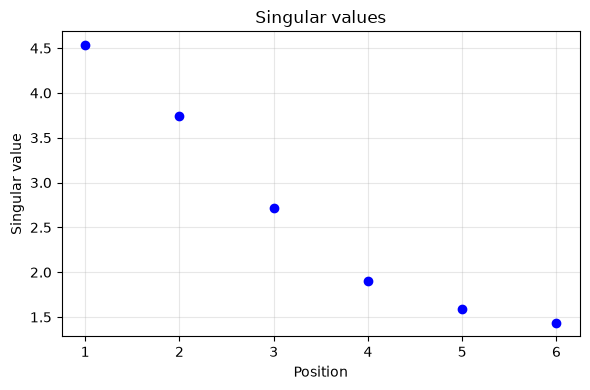

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: SVD of a matrix & verification
np.random.seed(42)
m_rows, n_cols = 10, 6

# matrix of random numbers from normal distribution
mat_A = np.random.randn(m_rows, n_cols)

# SVD
U_mat, s_vals, Vt_mat = np.linalg.svd(mat_A, full_matrices=True)
Sigma_mat = np.zeros((m_rows, n_cols))
Sigma_mat[:n_cols, :n_cols] = np.diag(s_vals)


A_reconstructed = U_mat @ Sigma_mat @ Vt_mat
frob_error = np.linalg.norm(A_reconstructed - mat_A, ord='fro')
numerical_rank = np.linalg.matrix_rank(mat_A)
nonzero_singulars = np.sum(s_vals > 1e-10)

print("=== Exercise 1: SVD Verification ===")
print(f"A shape: {mat_A.shape}, U: {U_mat.shape},  Sigma: {Sigma_mat.shape},  V: {Vt_mat.shape}")
print(f"Singular values: {s_vals, 4}")
print(f"Reconstruction Frobenius error: {frob_error:.2e}")
print(f"Numerical rank: {numerical_rank}  |  non-zero singular values: {nonzero_singulars}")

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(s_vals) + 1), s_vals, 'o', color='blue')
plt.xlabel('Position')
plt.ylabel('Singular value')
plt.title('Singular values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Exercise 2: Rank-k Approximation ===
  k=1  ||A-A_k||_F=5.4396  Eckart-Young bound=sqrt(sum s_i^2, i>k)=5.4396
  k=2  ||A-A_k||_F=3.9507  Eckart-Young bound=sqrt(sum s_i^2, i>k)=3.9507
  k=3  ||A-A_k||_F=2.8636  Eckart-Young bound=sqrt(sum s_i^2, i>k)=2.8636
  k=4  ||A-A_k||_F=2.1442  Eckart-Young bound=sqrt(sum s_i^2, i>k)=2.1442
  k=5  ||A-A_k||_F=1.4378  Eckart-Young bound=sqrt(sum s_i^2, i>k)=1.4378
  k=6  ||A-A_k||_F=0.0000  Eckart-Young bound=sqrt(sum s_i^2, i>k)=0.0000


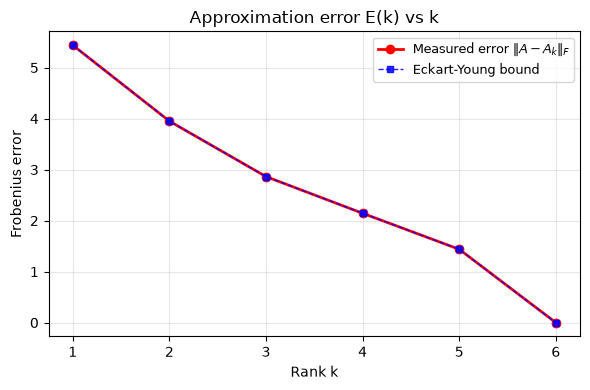

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 2: Best rank-k approximation
np.random.seed(42)
m_rows, n_cols = 10, 6
mat_A = np.random.randn(m_rows, n_cols)
U_mat, singular_values, Vt_mat = np.linalg.svd(mat_A, full_matrices=True)

def compute_rank_k_approx(k_rank, singular_values, left_vectors, right_vectors_t):
    m_dim, n_dim = left_vectors.shape[0], right_vectors_t.shape[1]
    A_k = np.zeros((m_dim, n_dim))
    for i in range(k_rank):
        A_k += singular_values[i] * (left_vectors[:, i:i+1] @ right_vectors_t[i:i+1, :])
    return A_k

print("=== Exercise 2: Rank-k Approximation ===")
k_indices = np.arange(1, min(m_rows, n_cols) + 1)
frobenius_errors = []
eckart_bounds = []

for k in k_indices:
    A_k = compute_rank_k_approx(k, singular_values, U_mat, Vt_mat)
    err_k = np.linalg.norm(mat_A - A_k, ord='fro')
    bound_k = np.sqrt(np.sum(singular_values[k:]**2))
    frobenius_errors.append(err_k)
    eckart_bounds.append(bound_k)
    print(f"  k={k}  ||A-A_k||_F={err_k:.4f}  Eckart-Young bound=sqrt(sum s_i^2, i>k)={bound_k:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(k_indices, frobenius_errors, 'o-', color='red', linewidth=2, markersize=6, label=r'Measured error $\|A - A_k\|_F$')
plt.plot(k_indices, eckart_bounds, 's--', color='blue', linewidth=1, markersize=5, alpha=0.85, label='Eckart-Young bound')
plt.xlabel('Rank k')
plt.ylabel('Frobenius error')
plt.title('Approximation error E(k) vs k')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Exercise 3: Image Compression ===
Image shape: (512, 512)  |  numerical rank: 512
Fraction of energy in top-k singular values:
  k=2     energy=92.03%  compression_factor=0.9922  ||X-X_k||_F=21474.7
  k=20    energy=98.98%  compression_factor=0.9218  ||X-X_k||_F=7699.9
  k=50    energy=99.60%  compression_factor=0.8045  ||X-X_k||_F=4836.1
  k=100   energy=99.85%  compression_factor=0.6090  ||X-X_k||_F=2992.1
  k=200   energy=99.97%  compression_factor=0.2180  ||X-X_k||_F=1342.4


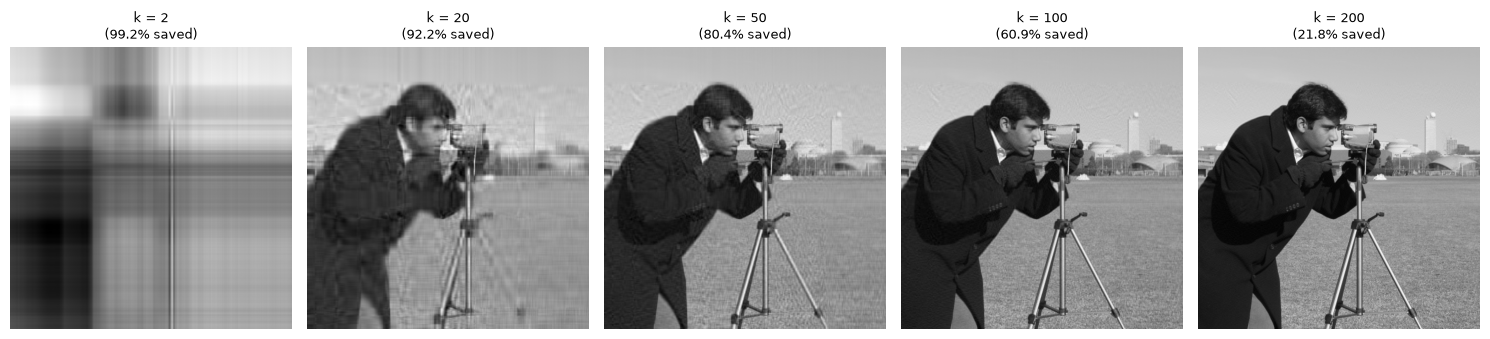

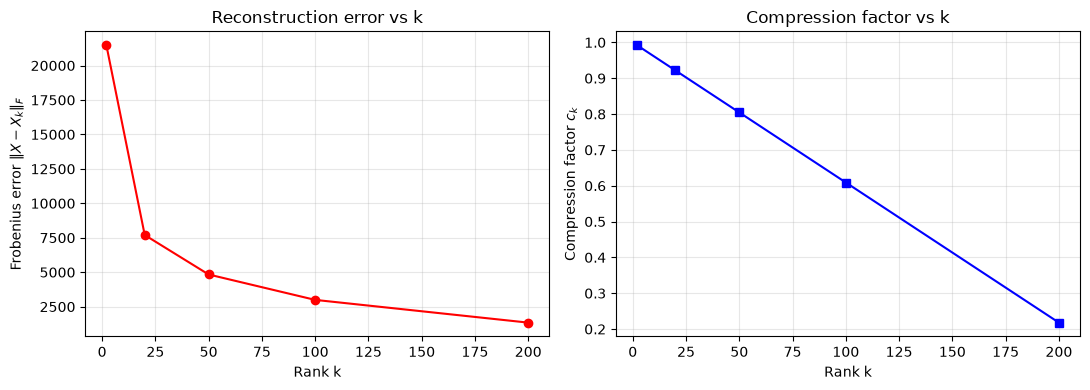

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import skimage

# Exercise 3: Image compression with SVD
X_image = skimage.data.camera().astype(float)
img_m, img_n = X_image.shape
U_img, s_img, Vt_img = np.linalg.svd(X_image)

def reconstruct_image_rank_k(k_comp, left_basis, sing_vals, right_basis_t):
    return left_basis[:, :k_comp] @ np.diag(sing_vals[:k_comp]) @ right_basis_t[:k_comp, :]

def get_compression_factor(k_comp, rows, cols):
    return 1.0 - (k_comp * (rows + cols + 1)) / (rows * cols)

print("=== Exercise 3: Image Compression ===")
print(f"Image shape: {X_image.shape}  |  numerical rank: {np.linalg.matrix_rank(X_image)}")
total_energy = np.sum(s_img**2)
print("Fraction of energy in top-k singular values:")

target_ranks = [2, 20, 50, 100, 200]
reconstruction_errors = []
compression_factors = []

plt.figure(figsize=(15, 3.5))
for plot_idx, k in enumerate(target_ranks):
    X_k = reconstruct_image_rank_k(k, U_img, s_img, Vt_img)
    err_frob = np.linalg.norm(X_image - X_k, ord='fro')
    comp_fact = get_compression_factor(k, img_m, img_n)
    energy_frac = np.sum(s_img[:k]**2) / total_energy
    
    reconstruction_errors.append(err_frob)
    compression_factors.append(comp_fact)
    
    print(f"  k={k:<3}   energy={energy_frac*100:.2f}%  compression_factor={comp_fact:.4f}  ||X-X_k||_F={err_frob:.1f}")
    
    plt.subplot(1, len(target_ranks), plot_idx + 1)
    plt.imshow(X_k, cmap='gray')
    plt.title(f'k = {k}\n({comp_fact*100:.1f}% saved)', fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Error and compression factor curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(target_ranks, reconstruction_errors, 'o-', color='red', linewidth=1.5, markersize=6)
axes[0].set_xlabel('Rank k')
axes[0].set_ylabel(r'Frobenius error $\|X - X_k\|_F$')
axes[0].set_title('Reconstruction error vs k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(target_ranks, compression_factors, 's-', color='blue', linewidth=1.5, markersize=6)
axes[1].set_xlabel('Rank k')
axes[1].set_ylabel('Compression factor $c_k$')
axes[1].set_title('Compression factor vs k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Exercise 4: PCA Clustering  |  dataset shape: (42000, 785) ===

Pair      N_train  N_test    Var k=2   Centroid dist
  3 vs 4      6738    1685     24.19%         1330.64


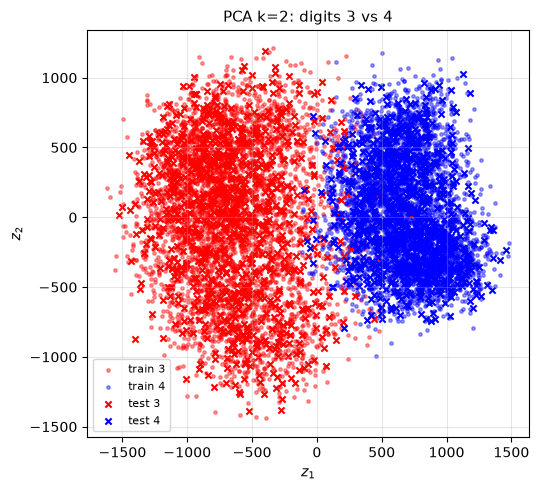

  2 vs 8      6592    1648     18.82%          978.26


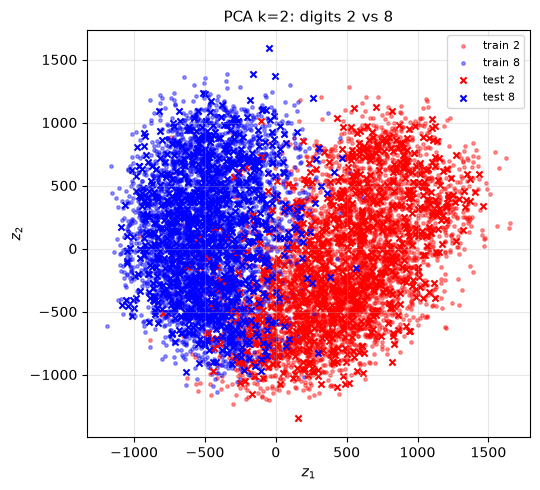

  1 vs 7      7268    1817     36.61%         1358.94


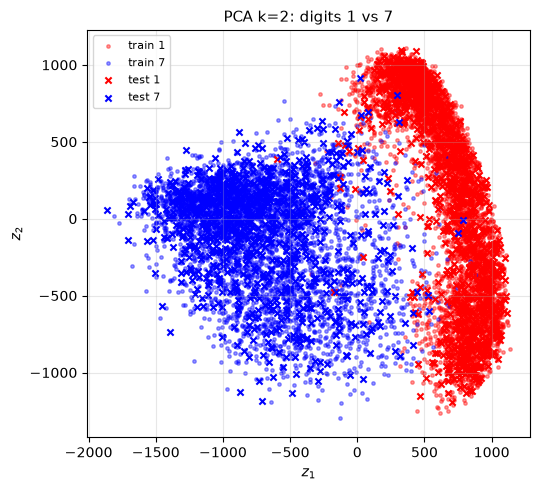


3 vs 4, k=3: explained variance = 29.88%


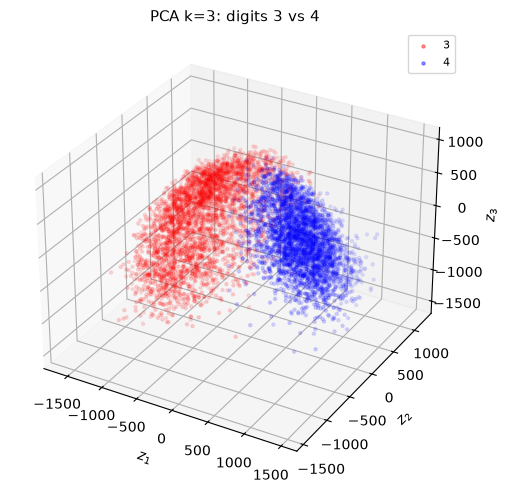

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# Exercise 4/5: PCA + Clustering on MNIST
np.random.seed(0)
csv_filepath = 'mnist.csv' if os.path.exists('mnist.csv') else 'answers/mnist.csv'
dataset_raw = pd.read_csv(csv_filepath).values
X_all = dataset_raw[:, 1:]
Y_all = dataset_raw[:, 0]
print(f"=== Exercise 4: PCA Clustering  |  dataset shape: {dataset_raw.shape} ===")

def split_data(X_data, Y_data, n_train):
    shuffled_idx = np.random.permutation(len(Y_data))
    train_slice = shuffled_idx[:n_train]
    test_slice = shuffled_idx[n_train:]
    return (X_data[train_slice], Y_data[train_slice]), (X_data[test_slice], Y_data[test_slice])

def run_pca(X_train_data, X_test_data, k_components=2):
    centroid = X_train_data.mean(axis=0, keepdims=True)
    Xc_train = X_train_data - centroid
    Xc_test = X_test_data - centroid
    _, singular_vals, Vt_matrix = np.linalg.svd(Xc_train, full_matrices=False)
    P_matrix = Vt_matrix[:k_components]
    Z_train = Xc_train @ P_matrix.T
    Z_test = Xc_test @ P_matrix.T
    return Z_train, Z_test, singular_vals, P_matrix, centroid

def explained_variance(singular_vals, k_comp):

    return np.sum(singular_vals[:k_comp]**2) / np.sum(singular_vals**2)

# Digit pairs to compare
digit_pairs = [(3, 4), (2, 8), (1, 7)]
print(f"\n{'Pair':<8} {'N_train':>8} {'N_test':>7} {'Var k=2':>10} {'Centroid dist':>15}")

for digit_a, digit_b in digit_pairs:
    pair_mask = (Y_all == digit_a) | (Y_all == digit_b)
    X_filtered, Y_filtered = X_all[pair_mask], Y_all[pair_mask]
    train_size = int(len(Y_filtered) * 0.8)
    (X_tr, Y_tr), (X_te, Y_te) = split_data(X_filtered, Y_filtered, train_size)
    
    Z_tr, Z_te, s_pca, _, _ = run_pca(X_tr, X_te, k_components=2)
    var_2d = explained_variance(s_pca, 2)
    centroid_a = Z_tr[Y_tr == digit_a].mean(axis=0)
    centroid_b = Z_tr[Y_tr == digit_b].mean(axis=0)
    separation_dist = np.linalg.norm(centroid_a - centroid_b)
    print(f"  {digit_a} vs {digit_b}  {len(Y_tr):>8} {len(Y_te):>7} {var_2d*100:>9.2f}% {separation_dist:>15.2f}")

    plt.figure(figsize=(5.5, 5))
    plt.scatter(Z_tr[Y_tr == digit_a, 0], Z_tr[Y_tr == digit_a, 1],
                color='red', alpha=0.4, s=6, marker='o', label=f'train {digit_a}')
    plt.scatter(Z_tr[Y_tr == digit_b, 0], Z_tr[Y_tr == digit_b, 1],
                color='blue', alpha=0.4, s=6, marker='o', label=f'train {digit_b}')
    plt.scatter(Z_te[Y_te == digit_a, 0], Z_te[Y_te == digit_a, 1],
                color='red', marker='x', s=20, label=f'test {digit_a}')
    plt.scatter(Z_te[Y_te == digit_b, 0], Z_te[Y_te == digit_b, 1],
                color='blue', marker='x', s=20, label=f'test {digit_b}')
    plt.title(f'PCA k=2: digits {digit_a} vs {digit_b}', fontsize=11)
    plt.xlabel(r'$z_1$', fontsize=10)
    plt.ylabel(r'$z_2$', fontsize=10)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3D PCA for digits 3 vs 4 (k=3)
mask_34 = (Y_all == 3) | (Y_all == 4)
X_34, Y_34 = X_all[mask_34], Y_all[mask_34]
(X_tr3, Y_tr3), (X_te3, Y_te3) = split_data(X_34, Y_34, int(len(Y_34) * 0.8))
Z_tr3, _, s_pca3, _, _ = run_pca(X_tr3, X_te3, k_components=3)
print(f"\n3 vs 4, k=3: explained variance = {explained_variance(s_pca3, 3)*100:.2f}%")

fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(Z_tr3[Y_tr3 == 3, 0], Z_tr3[Y_tr3 == 3, 1], Z_tr3[Y_tr3 == 3, 2],
             color='red', alpha=0.4, s=5, label='3')
ax3d.scatter(Z_tr3[Y_tr3 == 4, 0], Z_tr3[Y_tr3 == 4, 1], Z_tr3[Y_tr3 == 4, 2],
             color='blue', alpha=0.4, s=5, label='4')
ax3d.set_title('PCA k=3: digits 3 vs 4', fontsize=11)
ax3d.set_xlabel(r'$z_1$')
ax3d.set_ylabel(r'$z_2$')
ax3d.set_zlabel(r'$z_3$')
ax3d.legend(fontsize=8)
plt.tight_layout()
plt.show()

=== Exercise 6: PCA + Classification ===
Pair     Method                     Acc    Prec     Rec      F1
------------------------------------------------------------
  3 vs 4   Logistic (PCA)          0.9727  0.9557  0.9903  0.9727
  3 vs 4   Centroid (PCA)          0.9757  0.9613  0.9903  0.9756
           Centroid separation: 1330.64



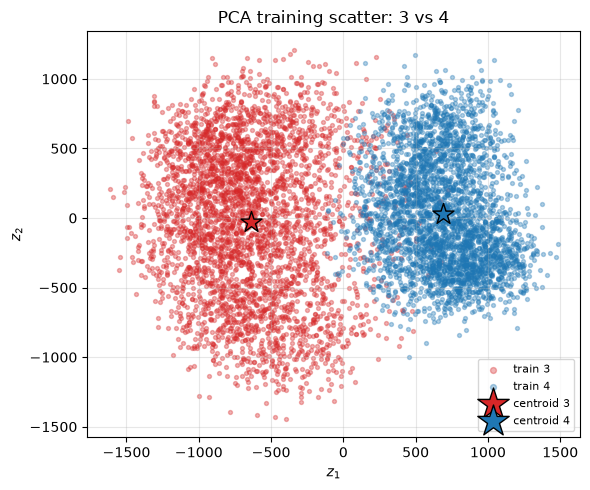

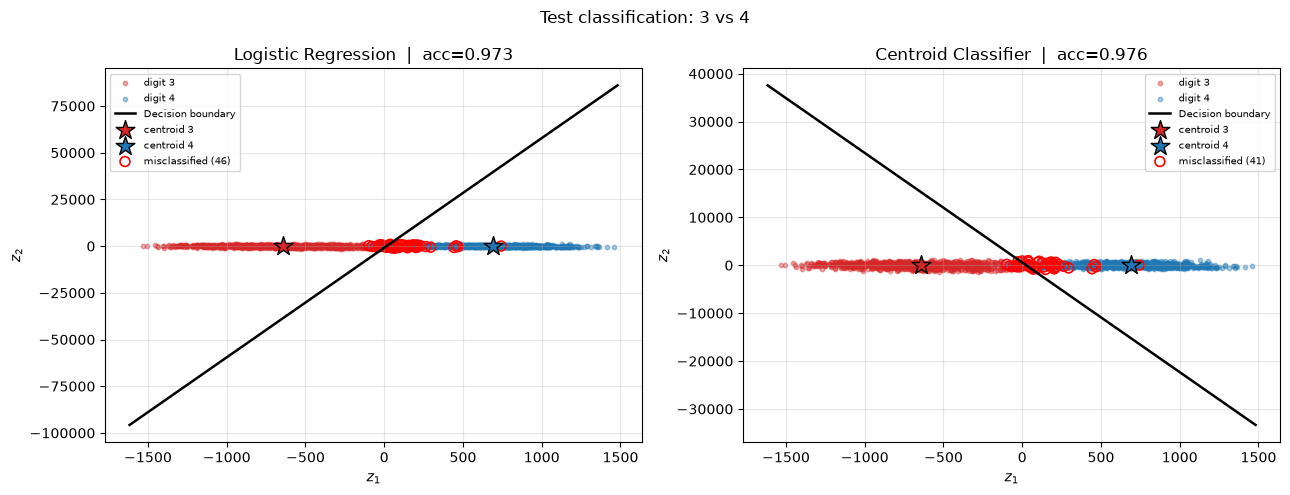

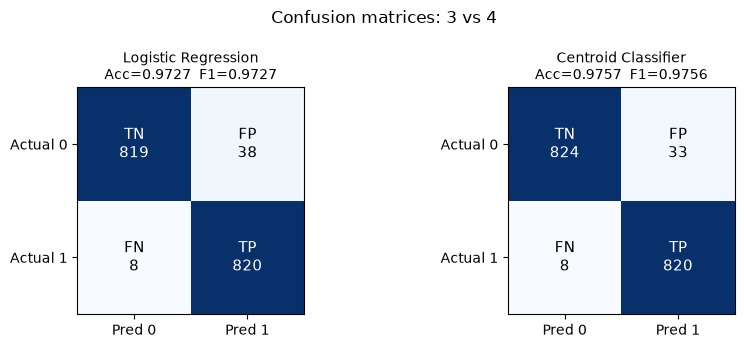

  1 vs 7   Logistic (PCA)          0.9725  0.9928  0.9497  0.9708
  1 vs 7   Centroid (PCA)          0.9653  0.9951  0.9325  0.9628
           Centroid separation: 1354.91



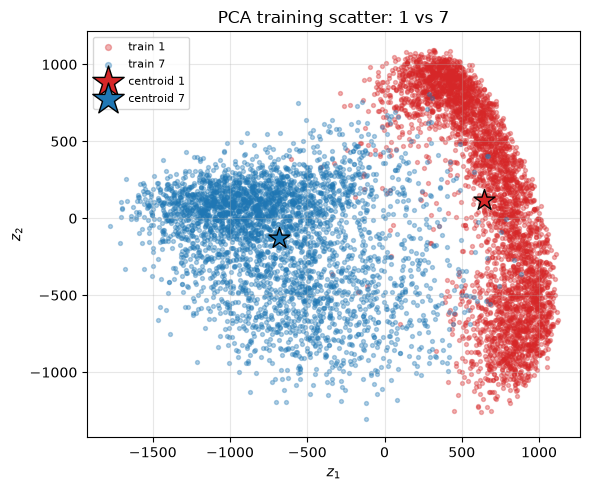

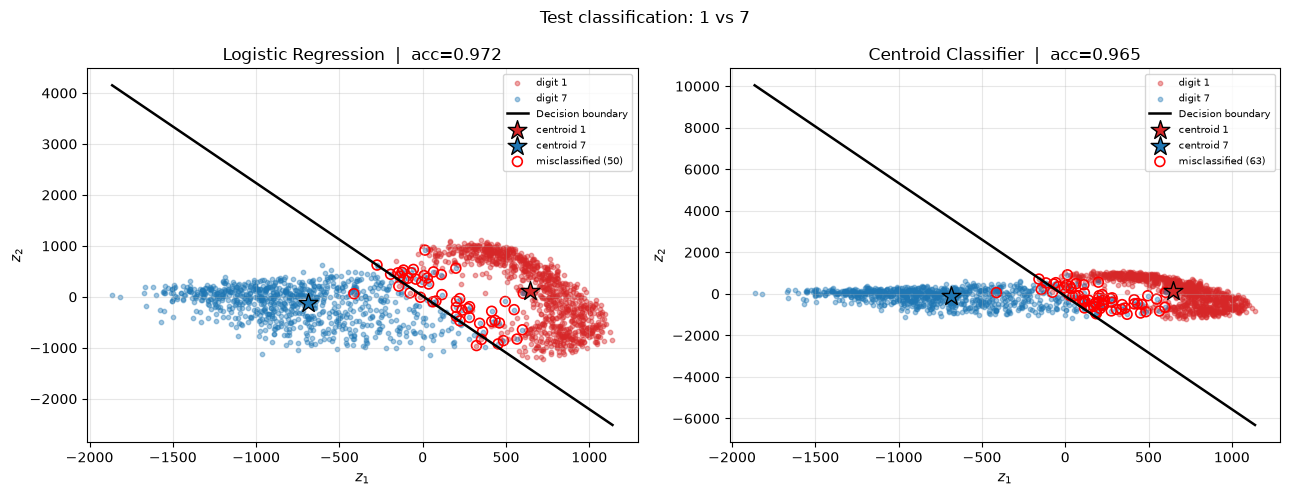

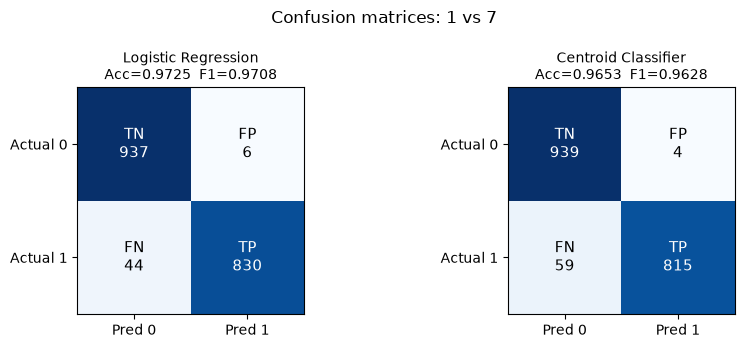

  2 vs 3   Logistic (PCA)          0.8945  0.8962  0.8983  0.8973
  2 vs 3   Centroid (PCA)          0.8974  0.8941  0.9074  0.9007
           Centroid separation: 1092.13



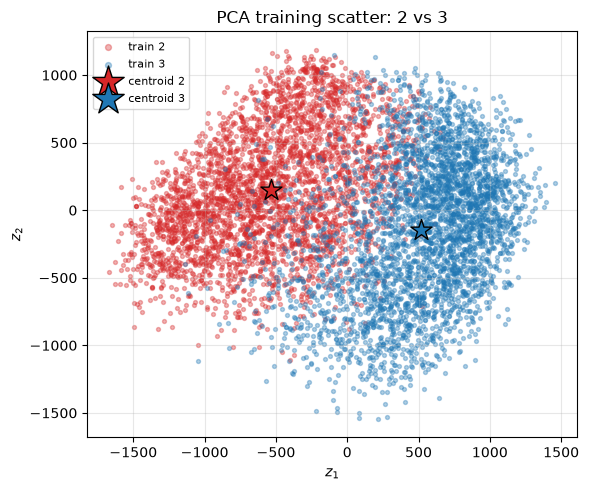

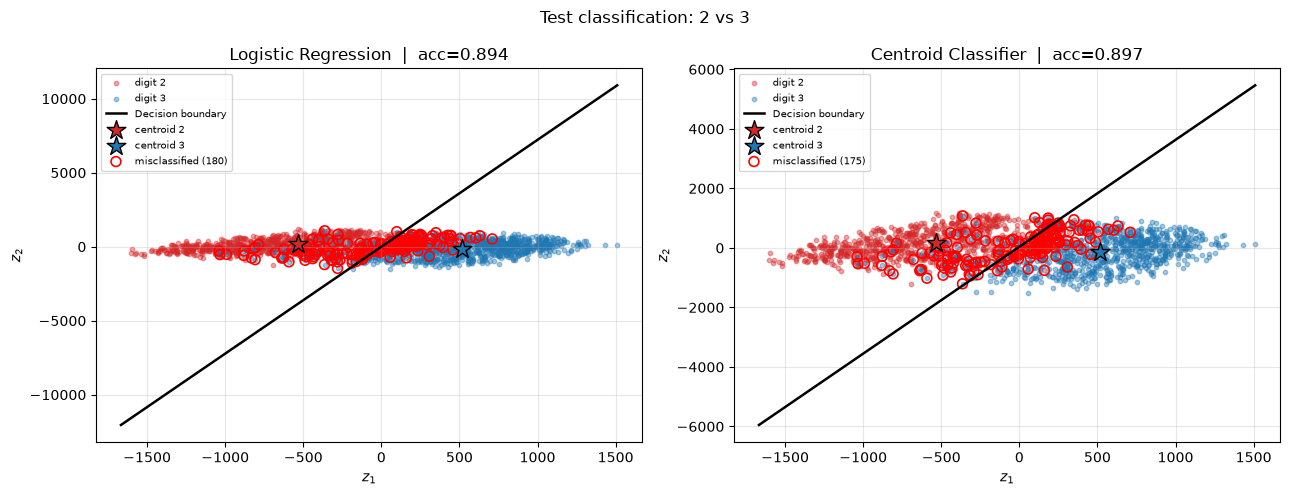

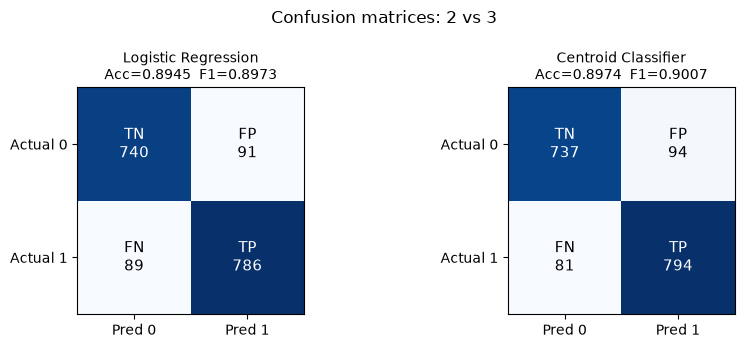

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Exercise 6: Classification after PCA (digits 3 vs 4, 1 vs 7, 2 vs 3)
np.random.seed(0)

csv_filepath = 'mnist.csv' if os.path.exists('mnist.csv') else 'answers/mnist.csv'
dataset_raw = pd.read_csv(csv_filepath).values
X_all = dataset_raw[:, 1:]
Y_all = dataset_raw[:, 0]

# ── Helpers ────────────────────────────────────────────────────────────────

def split_data(X_data, Y_data, n_train):
    shuffled_idx = np.random.permutation(len(Y_data))
    return (X_data[shuffled_idx[:n_train]], Y_data[shuffled_idx[:n_train]]), \
           (X_data[shuffled_idx[n_train:]], Y_data[shuffled_idx[n_train:]])

def sigmoid(z):
    z_clip = np.clip(z, -500, 500)
    return np.where(z_clip >= 0,
                    1.0 / (1.0 + np.exp(-z_clip)),
                    np.exp(z_clip) / (1.0 + np.exp(z_clip)))

def bce(theta, X_mat, y_targets):
    probs = np.clip(sigmoid(X_mat @ theta), 1e-12, 1.0 - 1e-12)
    return -np.mean(y_targets * np.log(probs) + (1.0 - y_targets) * np.log(1.0 - probs))

def grad_bce(theta, X_mat, y_targets):
    return (X_mat.T @ (sigmoid(X_mat @ theta) - y_targets)) / len(y_targets)

def SGD(theta_init, X_mat, y_targets, lr=1e-3, epochs=200, bs=32):
    theta = theta_init.copy()
    n_samples = len(y_targets)
    for _ in range(epochs):
        for batch_idx in np.array_split(np.random.permutation(n_samples),
                                        max(1, n_samples // bs)):
            theta -= lr * grad_bce(theta, X_mat[batch_idx], y_targets[batch_idx])
    return theta

def eval_metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    acc  = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return TP, FP, FN, TN, acc, prec, rec, f1

def centroid_classify(Z_test_pts, centroid_0, centroid_1):
    dist_0 = np.linalg.norm(Z_test_pts - centroid_0, axis=1)
    dist_1 = np.linalg.norm(Z_test_pts - centroid_1, axis=1)
    return (dist_1 < dist_0).astype(int)

def plot_confusion_matrix(ax, TP, FP, FN, TN, title=''):
    cm = np.array([[TN, FP], [FN, TP]])
    ax.imshow(cm, cmap='Blues')
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]}",
                    ha='center', va='center', fontsize=11,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['Actual 0', 'Actual 1'])
    ax.set_title(title, fontsize=10)

# ── Per digit-pair loop ────────────────────────────────────────────────────
print('=== Exercise 6: PCA + Classification ===')
print(f"{'Pair':<8} {'Method':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print('-' * 60)

for digit_a, digit_b in [(3, 4), (1, 7), (2, 3)]:

    mask = (Y_all == digit_a) | (Y_all == digit_b)
    X_filtered, Y_filtered = X_all[mask], Y_all[mask]
    (X_tr, Y_tr), (X_te, Y_te) = split_data(X_filtered, Y_filtered,
                                             int(len(Y_filtered) * 0.8))

    # Step 1: PCA k=2
    cX = X_tr.mean(axis=0, keepdims=True)
    _, _, Vt_mat = np.linalg.svd(X_tr - cX, full_matrices=False)
    P_mat = Vt_mat[:2]
    Z_tr  = (X_tr - cX) @ P_mat.T
    Z_te  = (X_te - cX) @ P_mat.T

    Z_tr_b   = np.hstack([np.ones((len(Z_tr), 1)), Z_tr])
    Z_te_b   = np.hstack([np.ones((len(Z_te), 1)), Z_te])
    y_tr_bin = (Y_tr == digit_b).astype(float)
    y_te_bin = (Y_te == digit_b).astype(int)

    # Step 2: Logistic regression
    np.random.seed(0)
    theta_weights = SGD(np.zeros(3), Z_tr_b, y_tr_bin)
    y_pred_lr = (sigmoid(Z_te_b @ theta_weights) >= 0.5).astype(int)
    TP,  FP,  FN,  TN,  acc,  prec,  rec,  f1  = eval_metrics(y_te_bin, y_pred_lr)

    # Step 3: Centroid classifier
    centroid_a = Z_tr[Y_tr == digit_a].mean(axis=0)
    centroid_b = Z_tr[Y_tr == digit_b].mean(axis=0)
    y_pred_nc  = centroid_classify(Z_te, centroid_a, centroid_b)
    TP2, FP2, FN2, TN2, acc2, prec2, rec2, f12 = eval_metrics(y_te_bin, y_pred_nc)
    separation = np.linalg.norm(centroid_a - centroid_b)

    print(f'  {digit_a} vs {digit_b}   {"Logistic (PCA)":<22} '
          f'{acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f}')
    print(f'  {digit_a} vs {digit_b}   {"Centroid (PCA)":<22} '
          f'{acc2:>7.4f} {prec2:>7.4f} {rec2:>7.4f} {f12:>7.4f}')
    print(f'           Centroid separation: {separation:.2f}\n')

    # LR decision boundary line
    t0, t1, t2 = theta_weights
    z1_min  = min(Z_tr[:, 0].min(), Z_te[:, 0].min())
    z1_max  = max(Z_tr[:, 0].max(), Z_te[:, 0].max())
    z1_line = np.linspace(z1_min, z1_max, 300)
    z2_lr   = -(t0 + t1 * z1_line) / t2

    # Centroid boundary: perpendicular bisector between the two centroids
    mid       = (centroid_a + centroid_b) / 2
    direction = centroid_b - centroid_a
    normal    = np.array([-direction[1], direction[0]])
    z2_cent   = mid[1] + (normal[1] / normal[0]) * (z1_line - mid[0])

    miss_lr = (y_pred_lr != y_te_bin)
    miss_nc = (y_pred_nc != y_te_bin)
    col_a, col_b = '#d62728', '#1f77b4'

    # Figure 1: Training scatter + centroids
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    ax1.scatter(Z_tr[Y_tr == digit_a, 0], Z_tr[Y_tr == digit_a, 1],
                color=col_a, s=8, alpha=0.35, label=f'train {digit_a}')
    ax1.scatter(Z_tr[Y_tr == digit_b, 0], Z_tr[Y_tr == digit_b, 1],
                color=col_b, s=8, alpha=0.35, label=f'train {digit_b}')
    ax1.scatter(*centroid_a, marker='*', color=col_a, edgecolor='k',
                s=250, zorder=5, label=f'centroid {digit_a}')
    ax1.scatter(*centroid_b, marker='*', color=col_b, edgecolor='k',
                s=250, zorder=5, label=f'centroid {digit_b}')
    ax1.set_title(f'PCA training scatter: {digit_a} vs {digit_b}')
    ax1.set_xlabel(r'$z_1$')
    ax1.set_ylabel(r'$z_2$')
    ax1.legend(fontsize=8, markerscale=1.5)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # LR vs Centroid side by side
    fig2, (ax_lr, ax_nc) = plt.subplots(1, 2, figsize=(13, 5))
    fig2.suptitle(f'Test classification: {digit_a} vs {digit_b}', fontsize=12)

    for ax, y_pred, z2_bound, miss, method_name, meth_acc in [
        (ax_lr, y_pred_lr, z2_lr,   miss_lr, 'Logistic Regression', acc),
        (ax_nc, y_pred_nc, z2_cent, miss_nc, 'Centroid Classifier',  acc2),
    ]:
        ax.scatter(Z_te[Y_te == digit_a, 0], Z_te[Y_te == digit_a, 1],
                   color=col_a, s=10, alpha=0.4, label=f'digit {digit_a}')
        ax.scatter(Z_te[Y_te == digit_b, 0], Z_te[Y_te == digit_b, 1],
                   color=col_b, s=10, alpha=0.4, label=f'digit {digit_b}')
        ax.plot(z1_line, z2_bound, 'k-', linewidth=1.8, label='Decision boundary')
        ax.scatter(*centroid_a, marker='*', color=col_a, edgecolor='k',
                   s=200, zorder=5, label=f'centroid {digit_a}')
        ax.scatter(*centroid_b, marker='*', color=col_b, edgecolor='k',
                   s=200, zorder=5, label=f'centroid {digit_b}')
        ax.scatter(Z_te[miss, 0], Z_te[miss, 1],
                   facecolors='none', edgecolors='red', s=50,
                   linewidth=1.2, label=f'misclassified ({miss.sum()})')
        ax.set_title(f'{method_name}  |  acc={meth_acc:.3f}')
        ax.set_xlabel(r'$z_1$')
        ax.set_ylabel(r'$z_2$')
        ax.legend(fontsize=7.5)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Figure 3: Confusion matrices side by side
    fig3, (cm_ax1, cm_ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
    fig3.suptitle(f'Confusion matrices: {digit_a} vs {digit_b}', fontsize=12)
    plot_confusion_matrix(cm_ax1, TP,  FP,  FN,  TN,
                          title=f'Logistic Regression\nAcc={acc:.4f}  F1={f1:.4f}')
    plot_confusion_matrix(cm_ax2, TP2, FP2, FN2, TN2,
                          title=f'Centroid Classifier\nAcc={acc2:.4f}  F1={f12:.4f}')
    plt.tight_layout()
    plt.show()
